# 星巴克门店数据分析

本实训针对一组关于全球星巴克门店的统计数据，使用 Matplotlib 和 Seaborn 库分析在不同国家和地区以及中国不同城市的星巴克门店数量。

In [32]:
# 1. 导入模块
import pandas as pd                       # 导入pandas，用于数据处理
import numpy as np                        # 导入numpy，用于数值计算
import matplotlib.pyplot as plt           # 导入matplotlib.pyplot，用于绘图
import seaborn as sns                     # 导入seaborn，高级可视化库
# 让生成的静态图嵌入notebook中
%matplotlib inline
# 设置中文字体，使图表中的中文能正常显示
plt.rcParams['font.sans-serif'] = ['SimHei']       # 设置字体为SimHei（黑体）
plt.rcParams['axes.unicode_minus'] = False         # 解决负号 '-' 显示为方块的问题
# 设置seaborn默认样式
sns.set()                                          # 使用seaborn默认样式

In [33]:
# 2. 获取数据
# 使用read_csv()函数读取星巴克门店数据（UTF-8编码）
starbucks = pd.read_csv('starbucks.csv', encoding='utf-8')
# 查看数据的前5行，了解数据结构
print(starbucks.head())
# 查看数据的基本信息（行列数、数据类型、缺失值等）
starbucks.info()
# 查看数据各列的统计信息
print(starbucks.describe(include='all'))

       Brand  Store Number        Store Name Ownership Type  \
0  Starbucks  47370-257954     Meritxell, 96       Licensed   
1  Starbucks  22331-212325  Ajman Drive Thru       Licensed   
2  Starbucks  47089-256771         Dana Mall       Licensed   
3  Starbucks  22126-218024        Twofour 54       Licensed   
4  Starbucks  17127-178586      Al Ain Tower       Licensed   

                    Street Address              City State/Province Country  \
0                Av. Meritxell, 96  Andorra la Vella              7      AD   
1             1 Street 69, Al Jarf             Ajman             AJ      AE   
2     Sheikh Khalifa Bin Zayed St.             Ajman             AJ      AE   
3                  Al Salam Street         Abu Dhabi             AZ      AE   
4  Khaldiya Area, Abu Dhabi Island         Abu Dhabi             AZ      AE   

  Postcode Phone Number                 Timezone  Longitude  Latitude  
0    AD500    376818720  GMT+1:00 Europe/Andorra       1.53     42.51  
1 

In [34]:
# 3. 数据预处理
# 查看数据的形状（行数 × 列数）
print(f'数据集形状：{starbucks.shape[0]} 行 × {starbucks.shape[1]} 列')
# 检查各列的缺失值情况
print('\n========== 各列缺失值统计 ==========')
print(starbucks.isnull().sum())
# 查看列名
print('\n========== 数据列名 ==========')
print(starbucks.columns.tolist())
# 查看各列的数据类型
print('\n========== 各列数据类型 ==========')
print(starbucks.dtypes)
# 数据字段说明：
# Brand           - 品牌名称
# Store Number    - 门店编号
# Store Name      - 门店名称
# Ownership Type  - 经营方式（Company Owned / Licensed / Joint Venture / Franchise）
# Street Address  - 街道地址
# City            - 所在城市
# State/Province  - 州/省
# Country         - 国家代码（两位字母代码）
# Postcode        - 邮政编码
# Phone Number    - 电话号码
# Timezone        - 时区
# Longitude       - 经度
# Latitude        - 纬度


数据集形状：25600 行 × 13 列

========== 各列缺失值统计 ==========
Brand                0
Store Number         0
Store Name           0
Ownership Type       0
Street Address       2
City                15
State/Province       0
Country              0
Postcode          1522
Phone Number      6861
Timezone             0
Longitude            1
Latitude             1
dtype: int64

========== 数据列名 ==========
['Brand', 'Store Number', 'Store Name', 'Ownership Type', 'Street Address', 'City', 'State/Province', 'Country', 'Postcode', 'Phone Number', 'Timezone', 'Longitude', 'Latitude']

========== 各列数据类型 ==========
Brand              object
Store Number       object
Store Name         object
Ownership Type     object
Street Address     object
City               object
State/Province     object
Country            object
Postcode           object
Phone Number       object
Timezone           object
Longitude         float64
Latitude          float64
dtype: object


In [42]:
# 4.1 查看星巴克旗下品牌，获取全球门店总数
# 查看星巴克旗下有哪些品牌
# 获取Brand列的唯一值
brands = starbucks['Brand'].unique()
for i, brand in enumerate(brands, 1):
    count = starbucks[starbucks['Brand'] == brand].shape[0]
    print(f'{i}. {brand}：{count} 家门店')

# 统计全球门店总数
total_stores = starbucks.shape[0]
print(f'全球星巴克门店总数：{total_stores} 家')

# 使用value_counts()快速统计各品牌门店数量
print('各品牌门店数量统计：')
brand_counts = starbucks['Brand'].value_counts()
brand_counts

1. Starbucks：25249 家门店
2. Teavana：348 家门店
3. Evolution Fresh：2 家门店
4. Coffee House Holdings：1 家门店
全球星巴克门店总数：25600 家
各品牌门店数量统计：


Brand
Starbucks                25249
Teavana                    348
Evolution Fresh              2
Coffee House Holdings        1
Name: count, dtype: int64

In [ ]:
# 4.2 查看全球共多少国家和地区开设了星巴克门店，显示前十
# 统计开设星巴克门店的国家和地区数量
# 按国家统计门店数量
country_counts = starbucks['Country'].value_counts()
# 获取国家/地区总数
total_countries = country_counts.shape[0]

print(f'全球共有 {total_countries} 个国家和地区开设了星巴克门店')
print('门店数量排名前10的国家/地区：')
print(country_counts.head(10))

# 设置显示格式，让输出更清晰
top10_countries = country_counts.head(10)
print('\n========== 前十国家/地区汇总表 ==========')
for i, (country, count) in enumerate(top10_countries.items(), 1):
    print(f'第{i:2d}名：{country}  —  {count:5d} 家门店')

全球共有 73 个国家和地区开设了星巴克门店

========== 门店数量排名前10的国家/地区 ==========
Country
US    13608
CN     2734
CA     1468
JP     1237
KR      993
GB      901
MX      579
TW      394
TR      326
PH      298
Name: count, dtype: int64

========== 前十国家/地区汇总表 ==========
第 1名：US  —  13608 家门店
第 2名：CN  —   2734 家门店
第 3名：CA  —   1468 家门店
第 4名：JP  —   1237 家门店
第 5名：KR  —    993 家门店
第 6名：GB  —    901 家门店
第 7名：MX  —    579 家门店
第 8名：TW  —    394 家门店
第 9名：TR  —    326 家门店
第10名：PH  —    298 家门店


### 4.3 绘制前十国家的分布情况

使用**柱形图**和**饼图**双图展示门店数量排名前十国家的分布情况，直观对比各国门店数量差异及占比。

C:\Users\yandifei\AppData\Local\Temp\ipykernel_49008\478972149.py:43: UserWarning: Glyph 22269 (\N{CJK UNIFIED IDEOGRAPH-56FD}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yandifei\AppData\Local\Temp\ipykernel_49008\478972149.py:43: UserWarning: Glyph 23478 (\N{CJK UNIFIED IDEOGRAPH-5BB6}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yandifei\AppData\Local\Temp\ipykernel_49008\478972149.py:43: UserWarning: Glyph 22320 (\N{CJK UNIFIED IDEOGRAPH-5730}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yandifei\AppData\Local\Temp\ipykernel_49008\478972149.py:43: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH-533A}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yandifei\AppData\Local\Temp\ipykernel_49008\478972149.py:43: UserWarning: Glyph 38376 (\N{CJK UNIFIED IDEOGRAPH-95E8}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yandifei\AppData\Local\Temp\ipykernel_49008\478972149.py:43: UserWarning: Glyph 24215 (\N{CJK UNIFIED IDEO

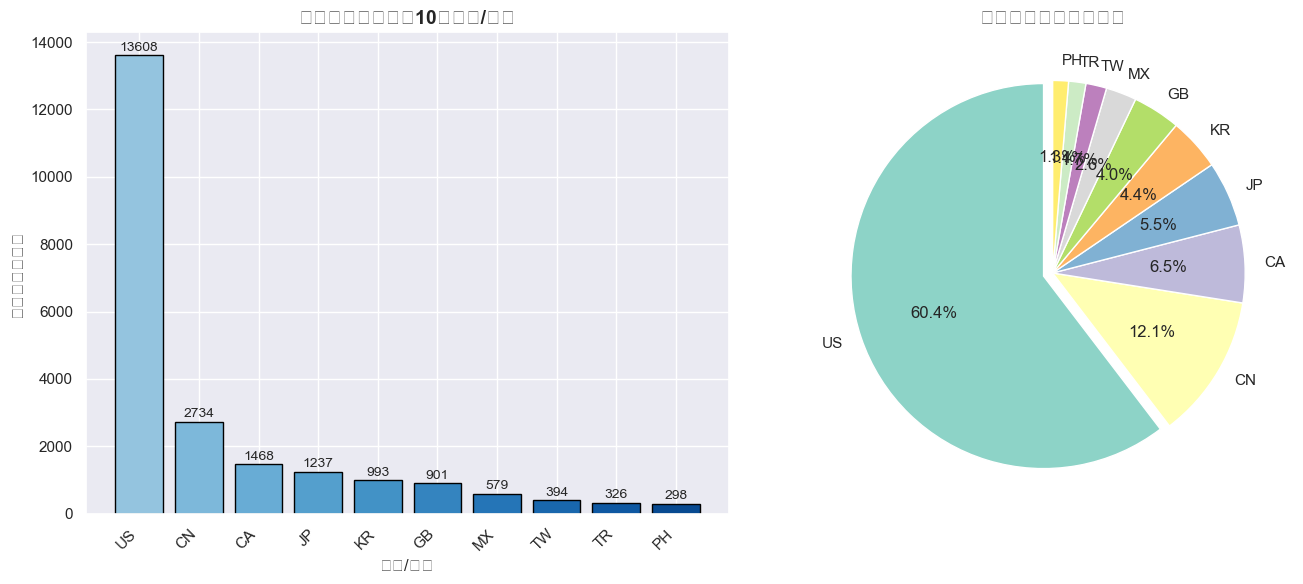

图表解读：美国（US）的星巴克门店数量远超其他国家/地区，占比超过半数。


In [37]:
# ============================================================
# 4.3 绘制前十国家的分布情况
# ============================================================

# 获取前十国家数据
top10_countries = country_counts.head(10)

# 创建画布，设置图片大小（宽14，高6）
plt.figure(figsize=(14, 6))

# ------------------------------------------------------------------
# 子图1：柱形图 — 展示前十国家门店数量
# ------------------------------------------------------------------
plt.subplot(1, 2, 1)
# 使用bar()绘制柱形图，color参数设置颜色方案
colors = plt.cm.Blues(np.linspace(0.4, 0.9, 10))   # 使用蓝色系渐变
bars = plt.bar(top10_countries.index, top10_countries.values, color=colors, edgecolor='black')
plt.title('星巴克门店数量前10的国家/地区', fontsize=14, fontweight='bold')
plt.xlabel('国家/地区', fontsize=12)
plt.ylabel('门店数量（家）', fontsize=12)
plt.xticks(rotation=45, ha='right')                  # 旋转x轴标签，避免重叠
# 在柱体上方标注数值
for bar, val in zip(bars, top10_countries.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(val), ha='center', va='bottom', fontsize=10)

# ------------------------------------------------------------------
# 子图2：饼图 — 展示前十国家门店数量占比
# ------------------------------------------------------------------
plt.subplot(1, 2, 2)
# 使用pie()绘制饼图
# explode: 突出显示第一名（美国），控制饼图各块的分离距离
explode = [0.05] + [0] * 9
plt.pie(top10_countries.values,
        labels=top10_countries.index,
        explode=explode,
        autopct='%1.1f%%',                     # 显示百分比，保留1位小数
        startangle=90,                         # 起始角度90度
        colors=plt.cm.Set3(np.linspace(0, 1, 10)))
plt.title('前十国家门店数量占比', fontsize=14, fontweight='bold')

# 调整子图之间的间距，防止标签重叠
plt.tight_layout()
plt.show()

print('图表解读：美国（US）的星巴克门店数量远超其他国家/地区，占比超过半数。')

### 4.4 显示拥有星巴克门店数量前10的城市

统计全球各城市星巴克门店数量，并列出排名前十的城市。

In [38]:
# ============================================================
# 4.4 显示拥有星巴克门店数量前10的城市
# ============================================================

# 按城市统计门店数量，降序排列
city_counts = starbucks['City'].value_counts()

print('========== 全球星巴克门店数量排名前10的城市 ==========')
print(city_counts.head(10))

# 汇总展示
top10_cities = city_counts.head(10)
print('\n========== 前十城市汇总表 ==========')
for i, (city, count) in enumerate(top10_cities.items(), 1):
    print(f'第{i:2d}名：{city:<20s}  —  {count:4d} 家门店')

========== 全球星巴克门店数量排名前10的城市 ==========
City
上海市            542
Seoul          243
北京市            234
New York       232
London         216
Toronto        192
Chicago        180
Mexico City    180
Seattle        156
Las Vegas      156
Name: count, dtype: int64

========== 前十城市汇总表 ==========
第 1名：上海市                   —   542 家门店
第 2名：Seoul                 —   243 家门店
第 3名：北京市                   —   234 家门店
第 4名：New York              —   232 家门店
第 5名：London                —   216 家门店
第 6名：Toronto               —   192 家门店
第 7名：Chicago               —   180 家门店
第 8名：Mexico City           —   180 家门店
第 9名：Seattle               —   156 家门店
第10名：Las Vegas             —   156 家门店


### 4.5 绘制前十城市的分布情况

使用**水平条形图**和**柱形图**双图展示全球门店数量前10城市的分布情况，水平条形图更适合展示城市名称（文本较长）。

C:\Users\yandifei\AppData\Local\Temp\ipykernel_49008\3486388104.py:39: UserWarning: Glyph 38376 (\N{CJK UNIFIED IDEOGRAPH-95E8}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yandifei\AppData\Local\Temp\ipykernel_49008\3486388104.py:39: UserWarning: Glyph 24215 (\N{CJK UNIFIED IDEOGRAPH-5E97}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yandifei\AppData\Local\Temp\ipykernel_49008\3486388104.py:39: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yandifei\AppData\Local\Temp\ipykernel_49008\3486388104.py:39: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yandifei\AppData\Local\Temp\ipykernel_49008\3486388104.py:39: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yandifei\AppData\Local\Temp\ipykernel_49008\3486388104.py:39: UserWarning: Glyph 23478 (\N{CJK UNIFIE

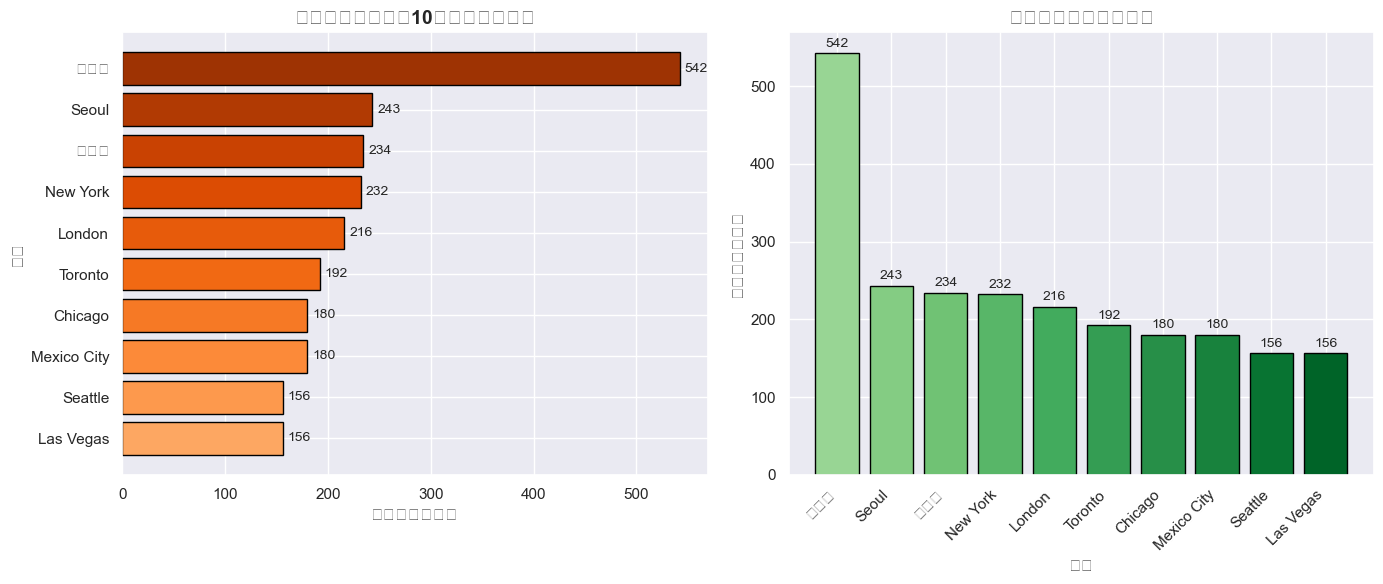

图表解读：上海在全球城市中星巴克门店数量排名第一，反映出星巴克在中国市场的深度布局。


In [39]:
# ============================================================
# 4.5 绘制前十城市的分布情况
# ============================================================

# 创建画布
plt.figure(figsize=(14, 6))

# ------------------------------------------------------------------
# 子图1：水平条形图 — 更清晰地展示城市名称
# ------------------------------------------------------------------
plt.subplot(1, 2, 1)
# 使用barh()绘制水平条形图（数据需逆序，使排名第一的显示在最上方）
top10_cities_asc = top10_cities[::-1]   # 倒序排列，让排名第一的在上方
colors = plt.cm.Oranges(np.linspace(0.4, 0.9, 10))
bars = plt.barh(top10_cities_asc.index, top10_cities_asc.values, color=colors, edgecolor='black')
plt.title('星巴克门店数量前10的城市（全球）', fontsize=14, fontweight='bold')
plt.xlabel('门店数量（家）', fontsize=12)
plt.ylabel('城市', fontsize=12)
# 在条形末端标注数值
for bar, val in zip(bars, top10_cities_asc.values):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(val), ha='left', va='center', fontsize=10)

# ------------------------------------------------------------------
# 子图2：柱形图 — 直观对比各城市门店数量
# ------------------------------------------------------------------
plt.subplot(1, 2, 2)
colors = plt.cm.Greens(np.linspace(0.4, 0.9, 10))
bars = plt.bar(range(len(top10_cities)), top10_cities.values, color=colors, edgecolor='black')
plt.title('前十城市门店数量对比', fontsize=14, fontweight='bold')
plt.xlabel('城市', fontsize=12)
plt.ylabel('门店数量（家）', fontsize=12)
plt.xticks(range(len(top10_cities)), top10_cities.index, rotation=45, ha='right')
# 在柱体上方标注数值
for bar, val in zip(bars, top10_cities.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print('图表解读：上海在全球城市中星巴克门店数量排名第一，反映出星巴克在中国市场的深度布局。')

### 4.6 按照星巴克门店在中国的分布情况，统计并绘制排名前10的城市

筛选出中国（CN）的数据，统计各城市门店数量并可视化。

========== 中国星巴克门店数量排名前10的城市 ==========
City
上海市          542
北京市          234
杭州市          117
深圳市          113
广州市          106
Hong Kong    104
成都市           98
苏州市           90
南京市           73
武汉市           67
Name: count, dtype: int64


C:\Users\yandifei\AppData\Local\Temp\ipykernel_49008\1458312905.py:46: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yandifei\AppData\Local\Temp\ipykernel_49008\1458312905.py:46: UserWarning: Glyph 28023 (\N{CJK UNIFIED IDEOGRAPH-6D77}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yandifei\AppData\Local\Temp\ipykernel_49008\1458312905.py:46: UserWarning: Glyph 24066 (\N{CJK UNIFIED IDEOGRAPH-5E02}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yandifei\AppData\Local\Temp\ipykernel_49008\1458312905.py:46: UserWarning: Glyph 21271 (\N{CJK UNIFIED IDEOGRAPH-5317}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yandifei\AppData\Local\Temp\ipykernel_49008\1458312905.py:46: UserWarning: Glyph 20140 (\N{CJK UNIFIED IDEOGRAPH-4EAC}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yandifei\AppData\Local\Temp\ipykernel_49008\1458312905.py:46: UserWarning: Glyph 26477 (\N{CJK UNIFIE

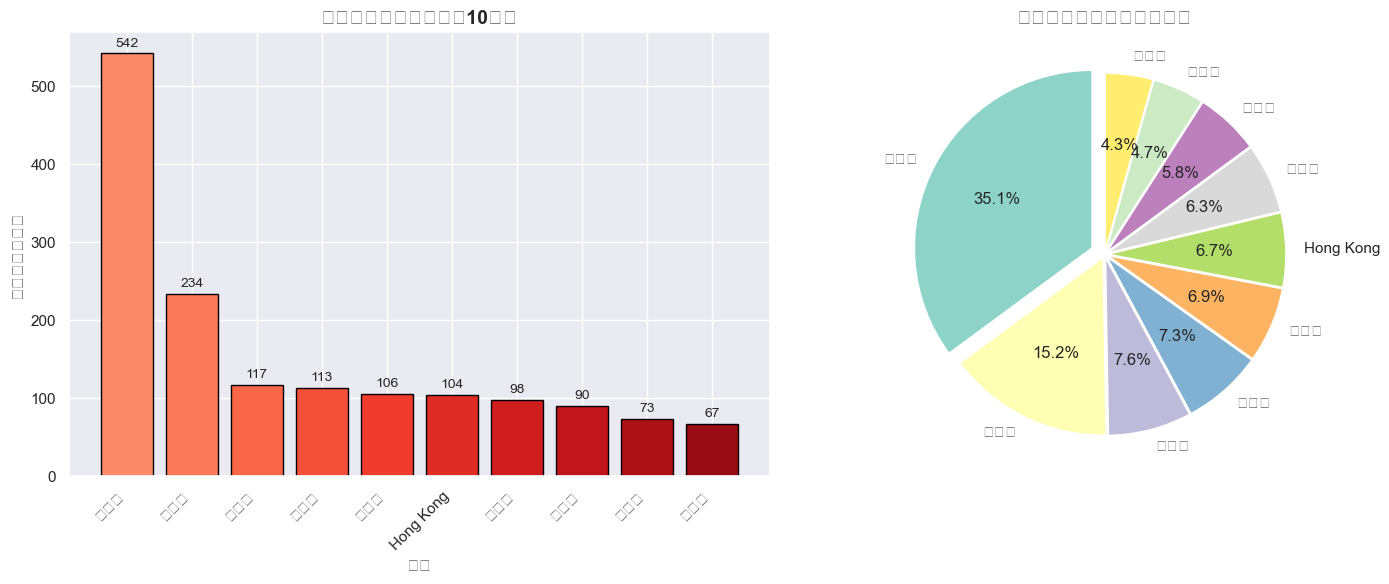


中国共有星巴克门店：2734 家
分布城市数量：197 个
图表解读：上海和北京的星巴克门店数量遥遥领先，前10城市主要集中在东部沿海发达地区。


In [40]:
# ============================================================
# 4.6 按照星巴克门店在中国的分布情况，统计并绘制排名前10的城市
# ============================================================

# 筛选中国地区的数据（国家代码为 'CN'）
china_starbucks = starbucks[starbucks['Country'] == 'CN']

# 统计中国各城市门店数量，降序排列
china_city_counts = china_starbucks['City'].value_counts()
print('========== 中国星巴克门店数量排名前10的城市 ==========')
print(china_city_counts.head(10))

# 获取前十数据
china_top10 = china_city_counts.head(10)

# ------------------------------------------------------------------
# 创建画布，使用subplots()创建双图展示
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 子图1：柱形图 — 展示中国前十城市的门店数量
colors = plt.cm.Reds(np.linspace(0.4, 0.9, 10))
bars = axes[0].bar(range(len(china_top10)), china_top10.values,
                   color=colors, edgecolor='black')
axes[0].set_title('中国星巴克门店数量前10城市', fontsize=14, fontweight='bold')
axes[0].set_xlabel('城市', fontsize=12)
axes[0].set_ylabel('门店数量（家）', fontsize=12)
axes[0].set_xticks(range(len(china_top10)))
axes[0].set_xticklabels(china_top10.index, rotation=45, ha='right')
# 在柱体上方标注数值
for bar, val in zip(bars, china_top10.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontsize=10)

# 子图2：饼图 — 展示各城市门店占比
# explode: 控制分离距离，突出上海
explode = [0.08] + [0.02] * 9
axes[1].pie(china_top10.values,
            labels=china_top10.index,
            explode=explode,
            autopct='%1.1f%%',
            startangle=90,
            colors=plt.cm.Set3(np.linspace(0, 1, 10)))
axes[1].set_title('中国前十城市门店数量占比', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\n中国共有星巴克门店：{china_starbucks.shape[0]} 家')
print(f'分布城市数量：{china_starbucks["City"].nunique()} 个')
print('图表解读：上海和北京的星巴克门店数量遥遥领先，前10城市主要集中在东部沿海发达地区。')

### 4.7 绘制星巴克门店的经营方式

分析星巴克门店的不同经营方式（Ownership Type）的分布情况，包括：
- Company Owned（公司直营）
- Licensed（授权经营）
- Joint Venture（合资经营）
- Franchise（特许经营）

========== 星巴克门店经营方式统计 ==========
Company Owned       ：11932 家  (46.6%)
Licensed            ： 9375 家  (36.6%)
Joint Venture       ： 3976 家  (15.5%)
Franchise           ：  317 家  (1.2%)


C:\Users\yandifei\AppData\Local\Temp\ipykernel_49008\1723533907.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ownership_counts.index, y=ownership_counts.values,
C:\Users\yandifei\AppData\Local\Temp\ipykernel_49008\1723533907.py:60: UserWarning: Glyph 26143 (\N{CJK UNIFIED IDEOGRAPH-661F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yandifei\AppData\Local\Temp\ipykernel_49008\1723533907.py:60: UserWarning: Glyph 24052 (\N{CJK UNIFIED IDEOGRAPH-5DF4}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yandifei\AppData\Local\Temp\ipykernel_49008\1723533907.py:60: UserWarning: Glyph 20811 (\N{CJK UNIFIED IDEOGRAPH-514B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yandifei\AppData\Local\Temp\ipykernel_49008\1723533907.py:60: UserWarning: Glyph 38376 (\N{CJK UNIFIED IDEOGRAPH-95E8}) missing from fon

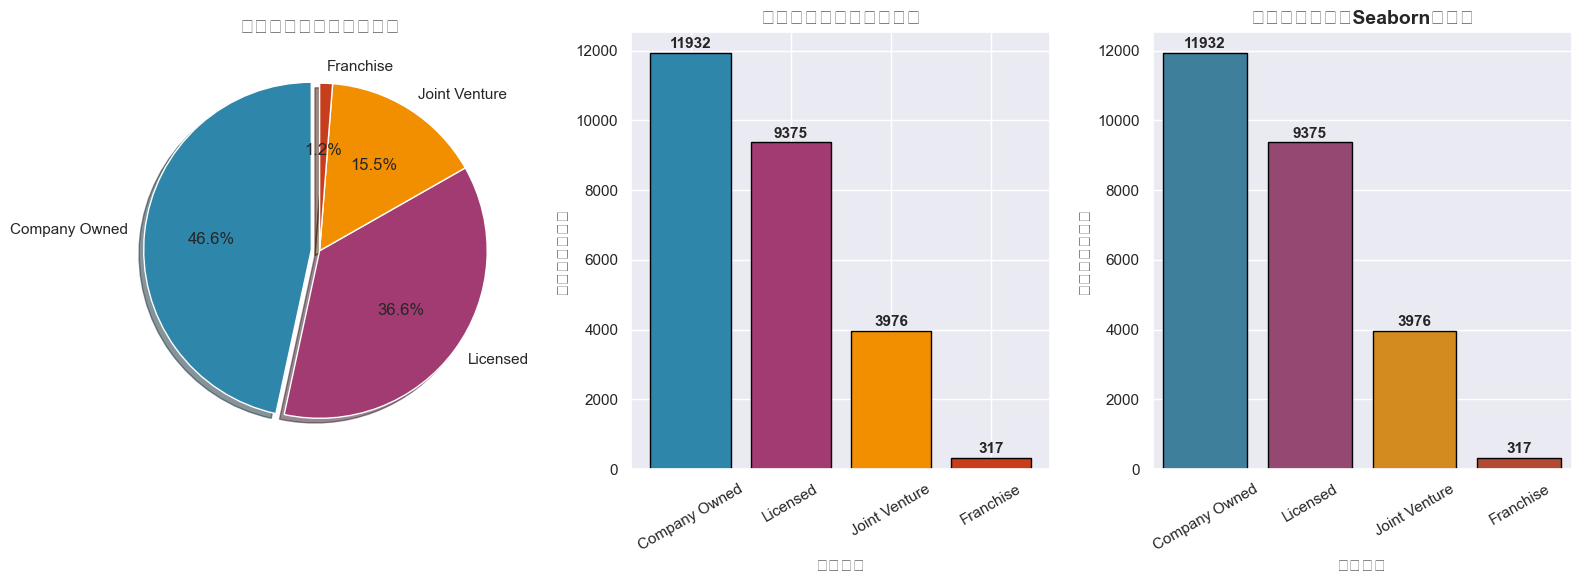


图表解读：公司直营（Company Owned）是星巴克最主要的经营方式，占比最高；
授权经营（Licensed）次之，合资（Joint Venture）和特许经营（Franchise）占比较小。


In [41]:
# ============================================================
# 4.7 绘制星巴克门店的经营方式
# ============================================================

# 统计各经营方式的门店数量
ownership_counts = starbucks['Ownership Type'].value_counts()
print('========== 星巴克门店经营方式统计 ==========')
for otype, count in ownership_counts.items():
    print(f'{otype:<20s}：{count:5d} 家  ({count/total_stores*100:.1f}%)')

# ------------------------------------------------------------------
# 创建画布，使用三图展示：饼图、matplotlib柱形图、seaborn柱形图
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# 定义颜色方案
ownership_colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

# ------------------------------------------------------------------
# 子图1：饼图 — 展示经营方式整体占比
# ------------------------------------------------------------------
axes[0].pie(ownership_counts.values,
            labels=ownership_counts.index,
            autopct='%1.1f%%',
            startangle=90,
            colors=ownership_colors,
            explode=(0.05, 0, 0, 0),           # 突出显示占比最大的Company Owned
            shadow=True)                         # 添加阴影效果
axes[0].set_title('星巴克门店经营方式占比', fontsize=14, fontweight='bold')

# ------------------------------------------------------------------
# 子图2：matplotlib柱形图 — 直观对比不同经营方式的数量
# ------------------------------------------------------------------
bars = axes[1].bar(ownership_counts.index, ownership_counts.values,
                   color=ownership_colors, edgecolor='black')
axes[1].set_title('各经营方式门店数量对比', fontsize=14, fontweight='bold')
axes[1].set_xlabel('经营方式', fontsize=12)
axes[1].set_ylabel('门店数量（家）', fontsize=12)
axes[1].tick_params(axis='x', rotation=30)
# 在柱体上方标注数值
for bar, val in zip(bars, ownership_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

# ------------------------------------------------------------------
# 子图3：使用seaborn的barplot()绘制带统计信息的柱形图
# 演示seaborn和matplotlib的混合使用，seaborn自动添加误差线
# ------------------------------------------------------------------
sns.barplot(x=ownership_counts.index, y=ownership_counts.values,
            palette=ownership_colors, ax=axes[2], edgecolor='black')
axes[2].set_title('经营方式分布（Seaborn风格）', fontsize=14, fontweight='bold')
axes[2].set_xlabel('经营方式', fontsize=12)
axes[2].set_ylabel('门店数量（家）', fontsize=12)
axes[2].tick_params(axis='x', rotation=30)
# 在柱体上方标注数值
for i, val in enumerate(ownership_counts.values):
    axes[2].text(i, val + 50, str(val), ha='center', va='bottom',
                 fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n图表解读：公司直营（Company Owned）是星巴克最主要的经营方式，占比最高；')
print('授权经营（Licensed）次之，合资（Joint Venture）和特许经营（Franchise）占比较小。')

## 实验总结

通过本实验对全球星巴克门店数据进行了全面的分析和可视化：

1. **品牌分析**：星巴克旗下包含 Starbucks、Teavana、Evolution Fresh、Coffee House Holdings 等品牌
2. **全球分布**：共在 73 个国家和地区开设了 25,600 家门店，美国占比最高
3. **城市分布**：上海是全球星巴克门店最多的城市
4. **中国市场**：中国门店主要集中在上海、北京等一线城市及东部沿海发达城市
5. **经营方式**：公司直营（Company Owned）是主要经营方式

本实验综合使用了 Matplotlib 的柱形图（bar/barh）、饼图（pie）、子图（subplot/subplots/add_subplot）以及 Seaborn 的 barplot 等可视化方法。